In [ ]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Regression Problem - Predict Math Scores

In [4]:
X = df.drop(columns=['math_score'])
y = df['math_score']

In [5]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [6]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [ ]:
# important - using column transformation - automate the column transformation part 
# (for categorical - one hot encoding, for numerical - normalization using standard scalar)

num_features = X.select_dtypes(exclude='str').columns
cat_features = X.select_dtypes(include='str').columns

normalizer = StandardScaler()
oh_encoder = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_encoder, cat_features),
        ("StandardScaler", normalizer, num_features)
    ]
)

In [8]:
# train test split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_cv, X_test, y_cv, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [9]:
# transform the data = fit the data (fit the data by X train and the transform the X_test)

print(X_train.shape, X_cv.shape, X_test.shape, y_train.shape, y_cv.shape, y_test.shape)

X_train = preprocessor.fit_transform(X_train)
X_cv = preprocessor.transform(X_cv)
X_test = preprocessor.transform(X_test)

(700, 7) (150, 7) (150, 7) (700,) (150,) (150,)


#### Model Evaluation

In [10]:
def evaluate_model(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    r2s = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mse, mae, r2s, rmse

In [11]:
# # important - training all the models togethor to compare the model performance

models_dic = {
    "LinearRegression"       : LinearRegression(),
    "LassoRegression"        : Lasso(),
    "RidgeRegression"        : Ridge(),
    "KNeighborsRegression"   : KNeighborsRegressor(),
    "SVRegression"           : SVR(),
    "DecisionTreeRegression" : DecisionTreeRegressor(),
    "RandomForestRegression" : RandomForestRegressor(),
    "AdaBoostRegression"     : AdaBoostRegressor(),
    "CatBoostRegression"     : CatBoostRegressor(verbose=False),
    "XGBRegression"          : XGBRegressor()
}

trained_model = []
train_score_r2s = []
cv_score_r2s = []
test_score_r2s = []

for model_name in models_dic:
    model = models_dic[model_name] # get the model

    model.fit(X_train, y_train) # train the model

    y_train_pred = model.predict(X_train) # get the predictions for X_train
    y_cv_pred = model.predict(X_cv) # get the predictions for X_cv
    y_test_pred = model.predict(X_test) # get the predictions for X_test

    mse_train, mae_train, r2s_train, rmse_train = evaluate_model(y_train, y_train_pred)
    mse_cv, mae_cv, r2s_cv, rmse_cv = evaluate_model(y_cv, y_cv_pred)
    mse_test, mae_test, r2s_test, rmse_test = evaluate_model(y_test, y_test_pred)

    print(f"Current model: {model_name}")
    print("for train Set: ")
    print(f"Mean squared error : {mse_train}")
    print(f'Mean absolute error : {mae_train}')
    print(f'R2 score : {r2s_train}')
    print(f'Root mean squared error : {rmse_train}')

    print("-----------------------------------------")

    print("for CV Set: ")
    print(f"Mean squared error : {mse_cv}")
    print(f'Mean absolute error : {mae_cv}')
    print(f'R2 score : {r2s_cv}')
    print(f'Root mean squared error : {rmse_cv}')

    print("========================================")
    print('\n')

    trained_model.append(model)
    train_score_r2s.append(r2s_train)
    cv_score_r2s.append(r2s_cv)
    test_score_r2s.append(r2s_test)


Current model: LinearRegression
for train Set: 
Mean squared error : 27.544689325007592
Mean absolute error : 4.198519565142326
R2 score : 0.8751313605993937
Root mean squared error : 5.248303471123559
-----------------------------------------
for CV Set: 
Mean squared error : 32.10848378478542
Mean absolute error : 4.517208345971241
R2 score : 0.8937505058981497
Root mean squared error : 5.666434839013453


Current model: LassoRegression
for train Set: 
Mean squared error : 42.30886309605581
Mean absolute error : 5.153151290773054
R2 score : 0.8082007712247247
Root mean squared error : 6.504526354474691
-----------------------------------------
for CV Set: 
Mean squared error : 54.92480717222357
Mean absolute error : 5.918596464752496
R2 score : 0.8182495002004522
Root mean squared error : 7.411127253813928


Current model: RidgeRegression
for train Set: 
Mean squared error : 27.548118224115534
Mean absolute error : 4.197720139010894
R2 score : 0.8751158163338113
Root mean squared err

In [ ]:
# get the model which performed the best - Linear Regression

pd.DataFrame(list(zip(models_dic.keys(),cv_score_r2s)), columns=["model_name", "R2_score_cv"]).sort_values("R2_score_cv", ascending=False)

,model_name,R2_score_cv
0,LinearRegression,0.893751
2,RidgeRegression,0.893587
8,CatBoostRegression,0.862769
6,RandomForestRegression,0.859950
7,AdaBoostRegression,0.840277
9,XGBRegression,0.837914
1,LassoRegression,0.818250
3,KNeighborsRegression,0.795472
5,DecisionTreeRegression,0.766335
4,SVRegression,0.681183


### Linear Regression

In [ ]:


lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 84.82


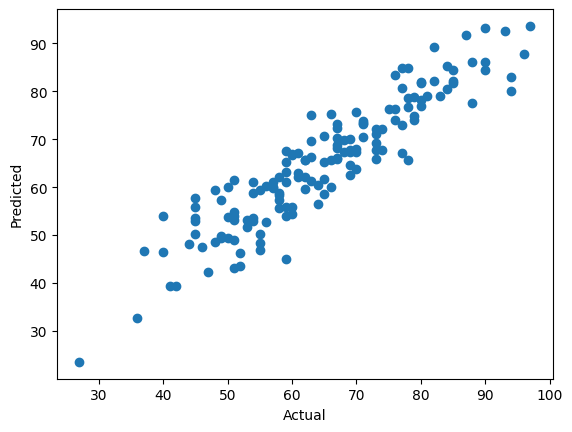

In [17]:
### Plotting the finals

plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

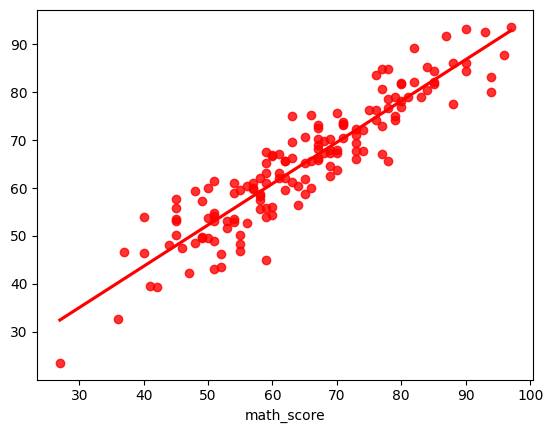

In [18]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [19]:
# difference between actual and predicted values

pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
557,61,67.109221,-6.109221
798,69,67.826005,1.173995
977,62,65.655456,-3.655456
136,51,48.947371,2.052629
575,40,53.956041,-13.956041
...,...,...,...
731,55,48.301243,6.698757
445,67,66.178782,0.821218
292,63,61.340167,1.659833
947,49,49.872130,-0.872130
